In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "C:\\Users\\luane\\Downloads\\matriz_final_v3_survivorship (1).csv",
    sep=","
)

# ajustando as colunas
numeric_cols = df.columns[df.dtypes != "object"]
df_numeric = df[numeric_cols]

In [28]:
# calcular retornos
returns = df_numeric.pct_change()
returns.describe()

,AAPL,ABBV,ABT,ACN,ADBE,AIG,AMD,AMGN,AMT,AMZN,...,UBER,UNH,UNP,UPS,USB,V,VZ,WFC,WMT,XOM
count,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,...,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000
mean,0.001080,0.000920,0.000441,0.000395,0.000323,0.000738,0.001555,0.000479,0.000092,0.000845,...,0.001167,0.000365,0.000398,0.000244,0.000381,0.000583,0.000040,0.000760,0.000850,0.000745
std,0.020070,0.015749,0.016096,0.018440,0.023742,0.024016,0.034000,0.016665,0.018718,0.022525,...,0.032887,0.021095,0.016885,0.019334,0.022964,0.017075,0.013473,0.023744,0.014508,0.020698
min,-0.128647,-0.130022,-0.097857,-0.093076,-0.167932,-0.208449,-0.146390,-0.082608,-0.151638,-0.140494,...,-0.216288,-0.223797,-0.130344,-0.141127,-0.144405,-0.135472,-0.074978,-0.158676,-0.113758,-0.122248
25%,-0.008249,-0.006733,-0.007274,-0.008334,-0.010291,-0.009326,-0.017122,-0.007694,-0.009284,-0.011155,...,-0.016063,-0.008057,-0.008020,-0.008706,-0.010642,-0.007243,-0.006338,-0.010382,-0.006076,-0.010354
50%,0.001140,0.001044,0.000595,0.001015,0.000723,0.001332,0.000023,0.000147,0.000080,0.000774,...,0.000000,0.000719,0.000787,0.000250,0.000000,0.001231,0.000081,0.000797,0.000774,0.000519
75%,0.011495,0.009013,0.008503,0.009512,0.012798,0.011487,0.020073,0.008381,0.009590,0.012955,...,0.017486,0.009385,0.008851,0.009650,0.011226,0.008611,0.006464,0.012050,0.007767,0.011689
max,0.153288,0.087174,0.109360,0.128573,0.177193,0.188083,0.238205,0.118180,0.122219,0.135359,...,0.382591,0.127989,0.130042,0.143758,0.173679,0.138427,0.092705,0.145346,0.117085,0.126868


In [31]:
# estratégia 1/N

n_assets = returns.shape[1]
weights_1N = np.ones(n_assets) / n_assets

portfolio_returns_1N = returns @ weights_1N
cumulative_returns_1N = (1 + portfolio_returns_1N).cumprod()

# métricas de performance

risk_free_rate = 0.0

annual_return = portfolio_returns_1N.mean() * 252 #retorno anualizado
volatility = portfolio_returns_1N.std() * np.sqrt(252) #volatilidade anualizada
sharpe_ratio = (annual_return - - risk_free_rate) / volatility # sharpe ratio

# máximo drawdown
cum_max = cumulative_returns_1N.cummax()
drawdown = cumulative_returns_1N / cum_max - 1
max_drawdown = drawdown.min()

print("Estratégia 1/N")
print(f"Retorno anualizado: {annual_return:.2%}")
print(f"Volatilidade anualizada: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Máximo Drawdown: {max_drawdown:.2%}")

Estratégia 1/N
Retorno anualizado: 18.30%
Volatilidade anualizada: 15.86%
Sharpe Ratio: 1.15
Máximo Drawdown: -22.82%


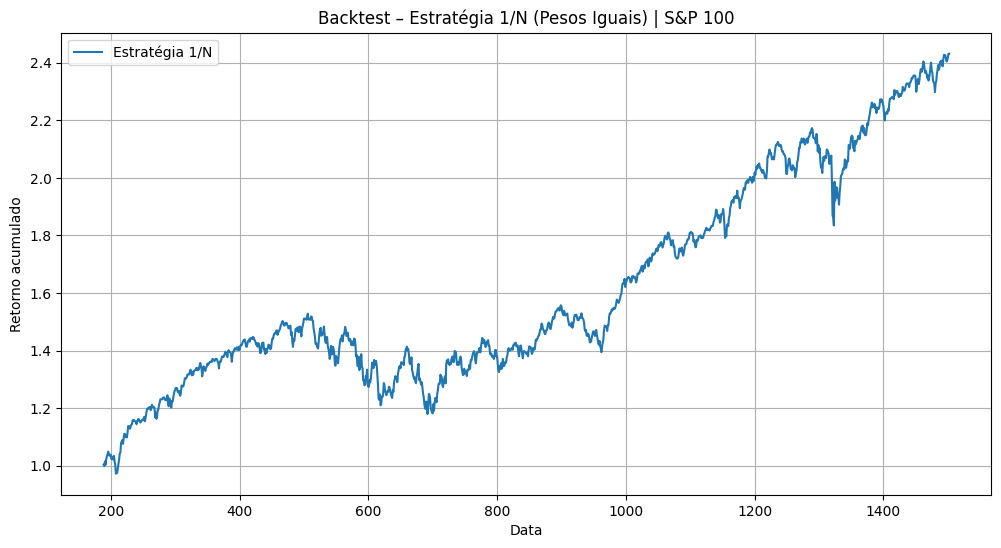

In [32]:
# gráfico
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_1N, label="Estratégia 1/N")
plt.title("Backtest – Estratégia 1/N (Pesos Iguais) | S&P 100")
plt.xlabel("Data")
plt.ylabel("Retorno acumulado")
plt.legend()
plt.grid(True)
plt.show()